### External noise
Edit the numbers marked `👈` and re-run.

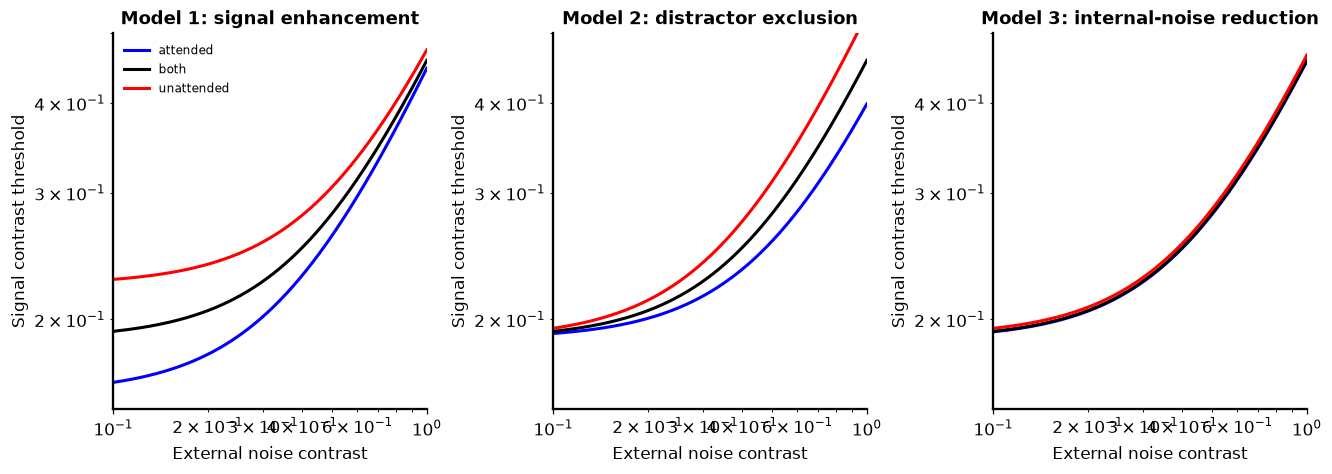

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})

# Lu & Dosher (1998): three models of attention give different contrast-threshold
# vs external-noise curves. Threshold contrast for a fixed d-prime.
dprime = 1.0
additive = 0.45          # 👈 additive internal noise sd
mult     = 0.0625        # 👈 multiplicative noise sd
beta     = 2.4           # 👈 perceptual-template gain
ext = np.linspace(1e-3, 1, 300)      # external noise contrast

def threshold(A_add=1.0, A_ext=1.0, A_mult=1.0):
    num = (1 + A_mult*mult**2) * (A_ext * ext**2) + additive**2 / A_add
    den = beta**2 * (1/dprime**2 - A_mult*mult**2)
    return np.sqrt(num / den)

models = {
    "Model 1: signal enhancement":  dict(att=dict(A_add=1.414), un=dict(A_add=0.707)),
    "Model 2: distractor exclusion": dict(att=dict(A_ext=0.707), un=dict(A_ext=1.414)),
    "Model 3: internal-noise reduction": dict(att=dict(A_mult=0.707/4), un=dict(A_mult=1.414*4)),
}

fig, axs = plt.subplots(1, 3, figsize=(12, 4.2), constrained_layout=True)
for ax, (name, m) in zip(axs, models.items()):
    ax.plot(ext, threshold(**m["att"]), "b", lw=2, label="attended")
    ax.plot(ext, threshold(),           "k", lw=2, label="both")
    ax.plot(ext, threshold(**m["un"]),  "r", lw=2, label="unattended")
    ax.set(xscale="log", yscale="log", xlim=(0.1, 1), ylim=(0.15, 0.5),
           xlabel="External noise contrast", title=name)
    ax.set_ylabel("Signal contrast threshold")
axs[0].legend(loc="upper left", fontsize=8)
plt.show()
